# 02 — Duplicate and Data Leakage Audit

This notebook performs exact-duplicate and near-duplicate analysis across
the residential defect datasets.

The purpose is to prevent visually identical or near-identical observations
from appearing across model-development and evaluation datasets.

Three data sources are examined:

1. Original public dataset
2. Additional public dataset
3. Independent field dataset

The independently collected field dataset must remain isolated from all
model-development data.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Install required package

In [2]:
!pip -q install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.1 MB/s eta 0:00:00


Import libraries

In [3]:
from pathlib import Path
from collections import defaultdict
from PIL import Image
import hashlib
import imagehash
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

Define paths

In [4]:
# ============================================================
# MAIN PAPER DIRECTORY
# ============================================================

PAPER_ROOT = Path(
    "/content/drive/MyDrive/Paper Dataset"
)

OUTPUT_DIR = (
    PAPER_ROOT /
    "Duplicate_Leakage_Check"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# ORIGINAL PUBLIC DATASET
# ============================================================

OLD_PUBLIC_IMAGES = Path(
    "/content/drive/MyDrive/YOLOV26_1/images"
)


# ============================================================
# ADDITIONAL PUBLIC DATASET
# ============================================================

NEW_PUBLIC_IMAGES = Path(
    "/content/drive/MyDrive/Paper Dataset/New Dataset/New Images"
)


# ============================================================
# INDEPENDENT FIELD DATASET
# ============================================================

FIELD_IMAGES = Path(
    "/content/drive/MyDrive/Paper Dataset/New Dataset/My Dataset/Images"
)


print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/content/drive/MyDrive/Paper Dataset/Duplicate_Leakage_Check


Supported image formats

In [5]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

Collect images from all three sources

In [6]:
def collect_images(folder, dataset_name):

    records = []

    for path in sorted(folder.iterdir()):

        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        ):

            records.append({
                "dataset": dataset_name,
                "filename": path.name,
                "path": str(path)
            })

    return records


records = []

records += collect_images(
    OLD_PUBLIC_IMAGES,
    "old_public"
)

records += collect_images(
    NEW_PUBLIC_IMAGES,
    "new_public"
)

records += collect_images(
    FIELD_IMAGES,
    "external_field"
)


images_df = pd.DataFrame(records)

print("Total images:", len(images_df))

print()
print(
    images_df["dataset"]
    .value_counts()
)

Total images: 4428

dataset
old_public        3204
new_public         662
external_field     562
Name: count, dtype: int64


Verify expected dataset counts

In [7]:
EXPECTED_COUNTS = {
    "old_public": 3204,
    "new_public": 662,
    "external_field": 562
}


print("=" * 70)
print("DATASET COUNT VERIFICATION")
print("=" * 70)

for dataset, expected in EXPECTED_COUNTS.items():

    actual = (
        images_df[
            images_df["dataset"] == dataset
        ].shape[0]
    )

    status = (
        "PASS"
        if actual == expected
        else "CHECK"
    )

    print(
        f"{dataset:<20}"
        f"Expected: {expected:<6}"
        f"Actual: {actual:<6}"
        f"{status}"
    )

DATASET COUNT VERIFICATION
old_public          Expected: 3204  Actual: 3204  PASS
new_public          Expected: 662   Actual: 662   PASS
external_field      Expected: 562   Actual: 562   PASS


Exact duplicate detection using SHA-256

In [8]:
def calculate_sha256(file_path):

    sha = hashlib.sha256()

    with open(file_path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha.update(chunk)

    return sha.hexdigest()

In [9]:
sha_values = []

for path in tqdm(
    images_df["path"],
    desc="Calculating SHA-256"
):

    sha_values.append(
        calculate_sha256(path)
    )

images_df["sha256"] = sha_values

Calculating SHA-256:   0%|          | 0/4428 [00:00<?, ?it/s]

Identify exact duplicate groups

In [10]:
exact_duplicate_df = (
    images_df[
        images_df.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values("sha256")
    .copy()
)

print(
    "Images involved in exact duplicates:",
    len(exact_duplicate_df)
)

print(
    "Exact duplicate groups:",
    exact_duplicate_df["sha256"].nunique()
)

Images involved in exact duplicates: 56
Exact duplicate groups: 18


Inspect exact duplicate groups

In [11]:
exact_duplicate_df[
    [
        "dataset",
        "filename",
        "sha256"
    ]
].head(30)

,dataset,filename,sha256
1038,old_public,img01039.jpg,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...
1072,old_public,img01073.jpg,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...
1357,old_public,img01358.jpg,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...
1230,old_public,img01231.jpg,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...
1099,old_public,img01100.jpg,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...
1362,old_public,img01363.jpg,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...
1041,old_public,img01042.jpg,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...
1260,old_public,img01261.jpg,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...
1419,old_public,img01420.jpg,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...
1332,old_public,img01333.jpg,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...


Check cross-dataset exact duplicates

In [12]:
cross_dataset_exact = []

for sha, group in exact_duplicate_df.groupby(
    "sha256"
):

    datasets = sorted(
        group["dataset"].unique()
    )

    if len(datasets) > 1:

        for _, row in group.iterrows():

            cross_dataset_exact.append({
                "sha256": sha,
                "dataset": row["dataset"],
                "filename": row["filename"],
                "path": row["path"],
                "datasets_in_group":
                    ", ".join(datasets)
            })


cross_dataset_exact_df = pd.DataFrame(
    cross_dataset_exact
)


print(
    "Images in cross-dataset exact duplicate groups:",
    len(cross_dataset_exact_df)
)

if len(cross_dataset_exact_df) > 0:

    print(
        "Cross-dataset exact duplicate groups:",
        cross_dataset_exact_df[
            "sha256"
        ].nunique()
    )

Images in cross-dataset exact duplicate groups: 0


Save exact duplicate results

In [13]:
images_df.to_csv(
    OUTPUT_DIR /
    "all_image_hashes.csv",
    index=False
)

exact_duplicate_df.to_csv(
    OUTPUT_DIR /
    "exact_duplicate_images.csv",
    index=False
)

cross_dataset_exact_df.to_csv(
    OUTPUT_DIR /
    "cross_dataset_exact_duplicates.csv",
    index=False
)

print("Exact duplicate results saved.")

Exact duplicate results saved.


Perceptual hash calculation

In [14]:
def calculate_phash(file_path):

    try:

        with Image.open(file_path) as img:

            img = img.convert("RGB")

            return str(
                imagehash.phash(img)
            )

    except Exception as e:

        return None

In [15]:
phash_values = []

for path in tqdm(
    images_df["path"],
    desc="Calculating perceptual hashes"
):

    phash_values.append(
        calculate_phash(path)
    )

images_df["phash"] = phash_values

Calculating perceptual hashes:   0%|          | 0/4428 [00:00<?, ?it/s]

Check failed image reads

In [16]:
failed_hashes = images_df[
    images_df["phash"].isna()
]

print(
    "Images that could not be processed:",
    len(failed_hashes)
)

failed_hashes

Images that could not be processed: 0


,dataset,filename,path,sha256,phash


Save perceptual hashes

In [17]:
images_df.to_csv(
    OUTPUT_DIR /
    "all_image_sha256_phash.csv",
    index=False
)

print("Hash database saved.")

Hash database saved.


Exact perceptual-hash matches

In [18]:
phash_exact_df = (
    images_df[
        images_df.duplicated(
            subset="phash",
            keep=False
        )
        &
        images_df["phash"].notna()
    ]
    .sort_values("phash")
)

print(
    "Images sharing identical perceptual hashes:",
    len(phash_exact_df)
)

print(
    "Identical pHash groups:",
    phash_exact_df[
        "phash"
    ].nunique()
)

Images sharing identical perceptual hashes: 63
Identical pHash groups: 21


Near-duplicate detection

In [19]:
PHASH_THRESHOLD = 6

In [20]:
valid_df = (
    images_df[
        images_df["phash"].notna()
    ]
    .reset_index(drop=True)
)

hash_objects = [
    imagehash.hex_to_hash(x)
    for x in valid_df["phash"]
]

Compare images for near duplicates

In [21]:
near_duplicate_pairs = []

n = len(valid_df)

for i in tqdm(
    range(n),
    desc="Searching near duplicates"
):

    hash_i = hash_objects[i]

    for j in range(i + 1, n):

        distance = (
            hash_i -
            hash_objects[j]
        )

        if distance <= PHASH_THRESHOLD:

            # Ignore files already known to be
            # byte-identical
            same_sha = (
                valid_df.iloc[i]["sha256"]
                ==
                valid_df.iloc[j]["sha256"]
            )

            near_duplicate_pairs.append({
                "dataset_1":
                    valid_df.iloc[i]["dataset"],

                "filename_1":
                    valid_df.iloc[i]["filename"],

                "path_1":
                    valid_df.iloc[i]["path"],

                "dataset_2":
                    valid_df.iloc[j]["dataset"],

                "filename_2":
                    valid_df.iloc[j]["filename"],

                "path_2":
                    valid_df.iloc[j]["path"],

                "phash_distance":
                    distance,

                "exact_sha_duplicate":
                    same_sha
            })

Searching near duplicates:   0%|          | 0/4428 [00:00<?, ?it/s]

Create near-duplicate table

In [22]:
near_duplicate_df = pd.DataFrame(
    near_duplicate_pairs
)

print(
    "Potential near-duplicate pairs:",
    len(near_duplicate_df)
)

near_duplicate_df.head(30)

Potential near-duplicate pairs: 128


,dataset_1,filename_1,path_1,dataset_2,filename_2,path_2,phash_distance,exact_sha_duplicate
0,old_public,img00096.jpg,/content/drive/MyDrive/YOLOV26_1/images/img000...,old_public,img00133.jpg,/content/drive/MyDrive/YOLOV26_1/images/img001...,0,True
1,old_public,img00096.jpg,/content/drive/MyDrive/YOLOV26_1/images/img000...,old_public,img00492.jpg,/content/drive/MyDrive/YOLOV26_1/images/img004...,0,True
2,old_public,img00133.jpg,/content/drive/MyDrive/YOLOV26_1/images/img001...,old_public,img00492.jpg,/content/drive/MyDrive/YOLOV26_1/images/img004...,0,True
3,old_public,img00307.jpg,/content/drive/MyDrive/YOLOV26_1/images/img003...,old_public,img00336.jpg,/content/drive/MyDrive/YOLOV26_1/images/img003...,6,False
4,old_public,img00633.jpg,/content/drive/MyDrive/YOLOV26_1/images/img006...,old_public,img01083.jpg,/content/drive/MyDrive/YOLOV26_1/images/img010...,0,True
5,old_public,img00668.jpg,/content/drive/MyDrive/YOLOV26_1/images/img006...,old_public,img01054.jpg,/content/drive/MyDrive/YOLOV26_1/images/img010...,0,True
6,old_public,img00668.jpg,/content/drive/MyDrive/YOLOV26_1/images/img006...,old_public,img01291.jpg,/content/drive/MyDrive/YOLOV26_1/images/img012...,0,True
7,old_public,img00668.jpg,/content/drive/MyDrive/YOLOV26_1/images/img006...,old_public,img01362.jpg,/content/drive/MyDrive/YOLOV26_1/images/img013...,0,True
8,old_public,img00668.jpg,/content/drive/MyDrive/YOLOV26_1/images/img006...,old_public,img01386.jpg,/content/drive/MyDrive/YOLOV26_1/images/img013...,0,True
9,old_public,img00794.jpg,/content/drive/MyDrive/YOLOV26_1/images/img007...,old_public,img00994.jpg,/content/drive/MyDrive/YOLOV26_1/images/img009...,2,False


Cross-dataset near duplicates

In [23]:
if len(near_duplicate_df) > 0:

    cross_dataset_near_df = (
        near_duplicate_df[
            near_duplicate_df["dataset_1"]
            !=
            near_duplicate_df["dataset_2"]
        ]
        .copy()
    )

else:

    cross_dataset_near_df = (
        pd.DataFrame()
    )


print(
    "Cross-dataset potential near duplicates:",
    len(cross_dataset_near_df)
)

Cross-dataset potential near duplicates: 1


Specifically check contamination of field data

In [24]:
if len(cross_dataset_near_df) > 0:

    field_overlap_df = (
        cross_dataset_near_df[
            (
                cross_dataset_near_df[
                    "dataset_1"
                ]
                ==
                "external_field"
            )
            |
            (
                cross_dataset_near_df[
                    "dataset_2"
                ]
                ==
                "external_field"
            )
        ]
        .copy()
    )

else:

    field_overlap_df = pd.DataFrame()


print(
    "Potential public ↔ field near-duplicate pairs:",
    len(field_overlap_df)
)

Potential public ↔ field near-duplicate pairs: 0


Save near-duplicate results

In [25]:
near_duplicate_df.to_csv(
    OUTPUT_DIR /
    "potential_near_duplicate_pairs.csv",
    index=False
)

cross_dataset_near_df.to_csv(
    OUTPUT_DIR /
    "cross_dataset_near_duplicates.csv",
    index=False
)

field_overlap_df.to_csv(
    OUTPUT_DIR /
    "potential_public_field_overlap.csv",
    index=False
)

print("Near-duplicate results saved.")

Near-duplicate results saved.


Final leakage summary

In [26]:
print("=" * 75)
print("DUPLICATE AND LEAKAGE AUDIT SUMMARY")
print("=" * 75)

print(
    f"Total images analysed                : "
    f"{len(images_df)}"
)

print(
    f"Exact duplicate images               : "
    f"{len(exact_duplicate_df)}"
)

print(
    f"Cross-dataset exact duplicate images : "
    f"{len(cross_dataset_exact_df)}"
)

print(
    f"Potential near-duplicate pairs       : "
    f"{len(near_duplicate_df)}"
)

print(
    f"Cross-dataset near-duplicate pairs   : "
    f"{len(cross_dataset_near_df)}"
)

print(
    f"Potential public-field overlap       : "
    f"{len(field_overlap_df)}"
)

print()
print(
    "Results saved to:"
)

print(OUTPUT_DIR)

DUPLICATE AND LEAKAGE AUDIT SUMMARY
Total images analysed                : 4428
Exact duplicate images               : 56
Cross-dataset exact duplicate images : 0
Potential near-duplicate pairs       : 128
Cross-dataset near-duplicate pairs   : 1
Potential public-field overlap       : 0

Results saved to:
/content/drive/MyDrive/Paper Dataset/Duplicate_Leakage_Check


## Duplicate-Audit Interpretation

Exact SHA-256 matching was used to identify byte-identical image files.

Perceptual hashing was subsequently used to identify potentially duplicated
or highly similar images that may have undergone resizing, recompression or
minor image transformations.

Perceptual-hash matches are treated as candidate near duplicates rather than
automatically removed observations. Candidate pairs require review before
exclusion or grouping.

Particular attention is given to possible overlap between the public
model-development corpus and the independently collected field dataset,
because the latter is reserved exclusively for external validation.

Cross-Dataset Near-Duplicate Inspection

In [27]:
cross_dataset_near_df[
    [
        "dataset_1",
        "filename_1",
        "dataset_2",
        "filename_2",
        "phash_distance",
        "exact_sha_duplicate"
    ]
]

,dataset_1,filename_1,dataset_2,filename_2,phash_distance,exact_sha_duplicate
110,old_public,img02889.jpg,new_public,images_1369.jpg,6,False


 Exact Duplicate Distribution by Dataset

In [28]:
exact_duplicate_df.groupby(
    ["dataset"]
).size()

,0
dataset,
old_public,56


Exact Duplicate Group Analysis

In [29]:
duplicate_group_summary = (
    exact_duplicate_df
    .groupby("sha256")
    .agg(
        group_size=("filename", "size"),
        datasets=("dataset", lambda x: ", ".join(sorted(set(x)))),
        files=("filename", lambda x: " | ".join(x))
    )
    .sort_values("group_size", ascending=False)
    .reset_index()
)

print("Number of exact duplicate groups:",
      len(duplicate_group_summary))

duplicate_group_summary

Number of exact duplicate groups: 18


,sha256,group_size,datasets,files
0,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,6,old_public,img01301.jpg | img01402.jpg | img01257.jpg | i...
1,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,5,old_public,img01358.jpg | img01231.jpg | img01100.jpg | i...
2,b45498bf10958d6b0d4b8aac4d4c25c176f1b5b880da0f...,5,old_public,img01362.jpg | img01386.jpg | img00668.jpg | i...
3,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...,5,old_public,img01261.jpg | img01420.jpg | img01333.jpg | i...
4,6d756acbc56c8545d5f48b68ea64e78f648a79a4777d6d...,4,old_public,img01214.jpg | img01082.jpg | img01274.jpg | i...
5,789f957702000677a33103b1894c10fe9d0055d514d529...,4,old_public,img01548.jpg | img01697.jpg | img01828.jpg | i...
6,b88fa7fa49bc31ecd92c22d382a95fec608a55ae619cd7...,3,old_public,img01132.jpg | img01112.jpg | img01258.jpg
7,77d041a89f9729181422761cecb2301f99e4ef25e1c844...,3,old_public,img00096.jpg | img00492.jpg | img00133.jpg
8,f24e6aefe7dcb2ceedcadf86ba648452946e25276761e5...,3,old_public,img01075.jpg | img01148.jpg | img01234.jpg
9,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...,2,old_public,img01039.jpg | img01073.jpg


Visual Verification of Cross-Dataset Near-Duplicate Candidate

The cross-dataset candidate identified by perceptual hashing is displayed
side-by-side for manual verification.

A perceptual-hash match is not automatically considered a duplicate because
different building-defect images may exhibit similar visual characteristics.

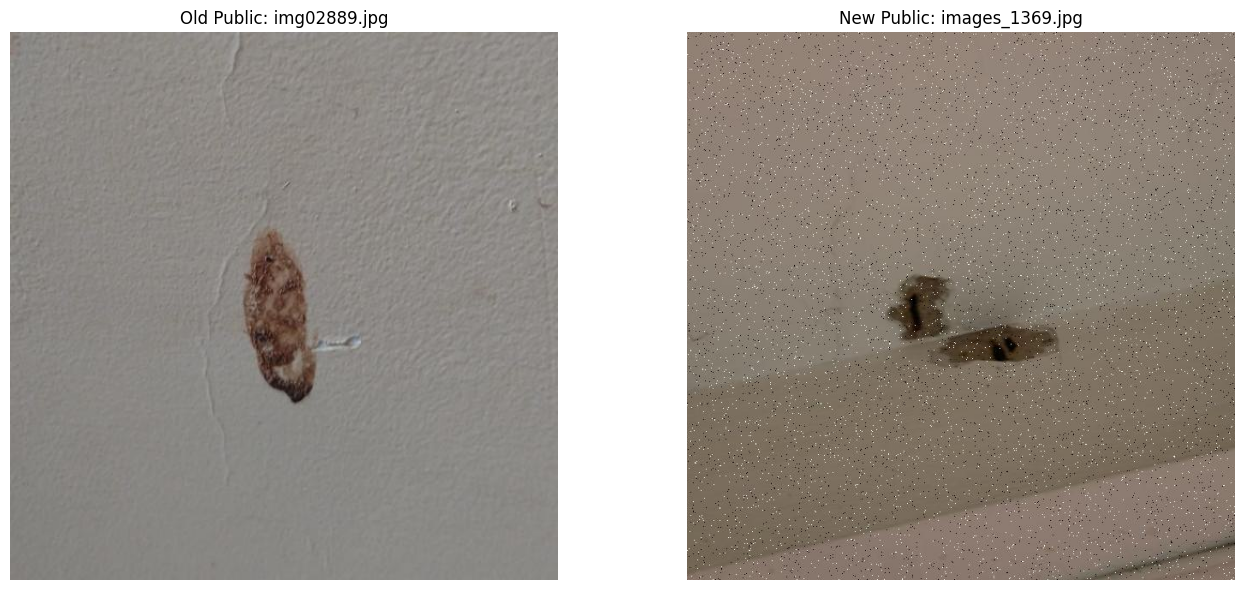

In [30]:
import matplotlib.pyplot as plt
from PIL import Image

img1_path = OLD_PUBLIC_IMAGES / "img02889.jpg"
img2_path = NEW_PUBLIC_IMAGES / "images_1369.jpg"

img1 = Image.open(img1_path).convert("RGB")
img2 = Image.open(img2_path).convert("RGB")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Old Public: img02889.jpg")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("New Public: images_1369.jpg")
plt.axis("off")

plt.tight_layout()
plt.show()

Non-Exact Near-Duplicate Candidate Analysis

Exact SHA-256 duplicates are excluded from the perceptual-similarity analysis
so that the remaining pairs represent only non-identical files that may be
visually similar.

These candidates are retained for further review rather than automatically
removed.

In [31]:
true_near_duplicates = near_duplicate_df[
    near_duplicate_df["exact_sha_duplicate"] == False
].copy()

print("=" * 70)
print("NON-EXACT NEAR-DUPLICATE ANALYSIS")
print("=" * 70)

print(
    "Non-exact near-duplicate candidates:",
    len(true_near_duplicates)
)

display(
    true_near_duplicates[
        [
            "dataset_1",
            "filename_1",
            "dataset_2",
            "filename_2",
            "phash_distance"
        ]
    ]
    .sort_values("phash_distance")
    .head(30)
)

NON-EXACT NEAR-DUPLICATE ANALYSIS
Non-exact near-duplicate candidates: 53


,dataset_1,filename_1,dataset_2,filename_2,phash_distance
75,old_public,img01448.jpg,old_public,img01740.jpg,0
116,new_public,din_57.jpg,new_public,din_97.jpg,0
115,new_public,din_12.jpg,new_public,din_97.jpg,0
114,new_public,din_12.jpg,new_public,din_57.jpg,0
126,external_field,IMG_0844.JPG,external_field,IMG_0845.JPG,0
9,old_public,img00794.jpg,old_public,img00994.jpg,2
105,old_public,img02774.jpg,old_public,img03177.jpg,2
112,old_public,img02931.jpg,old_public,img03197.jpg,2
111,old_public,img02906.jpg,old_public,img03053.jpg,2
123,new_public,images_1473.jpg,new_public,images_1475.jpg,2


## 30. Perceptual-Hash Distance Distribution

The distribution of perceptual-hash (pHash) distances is examined for all
non-exact near-duplicate candidates.

Smaller Hamming distances indicate greater perceptual similarity. Candidate
pairs are not considered true duplicates solely on the basis of pHash distance.

In [32]:
phash_distance_distribution = (
    true_near_duplicates[
        "phash_distance"
    ]
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("PERCEPTUAL-HASH DISTANCE DISTRIBUTION")
print("=" * 70)

print(phash_distance_distribution)

PERCEPTUAL-HASH DISTANCE DISTRIBUTION
phash_distance
0     5
2     6
4    14
6    28
Name: count, dtype: int64


## 31. Exact-Duplicate Annotation Consistency Audit

Exact duplicate images should ideally contain equivalent annotations.

This analysis compares YOLO annotation files within each exact-duplicate image
group to identify possible inconsistencies in class labels or bounding-box
annotations.

Annotation disagreement among identical images may indicate annotation noise
and must be resolved before dataset construction and model training.

In [33]:
OLD_PUBLIC_LABELS = Path(
    "/content/drive/MyDrive/YOLOV26_1/labels"
)

CLASS_NAMES = {
    0: "biological_growth",
    1: "stain",
    2: "crack",
    3: "peeling",
    4: "spalling"
}


def read_yolo_annotation(label_path):

    if not label_path.exists():
        return []

    text = label_path.read_text(
        errors="ignore"
    ).strip()

    if text == "":
        return []

    annotations = []

    for line in text.splitlines():

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))

        bbox = tuple(
            round(float(x), 6)
            for x in parts[1:]
        )

        annotations.append(
            (class_id, bbox)
        )

    # Sort so row ordering in the TXT file
    # does not create a false disagreement.
    return sorted(annotations)

## 32. Annotation Agreement Within Exact-Duplicate Groups

For each SHA-256 duplicate group, annotations are compared between all
identical image files.

Two levels of agreement are evaluated:

1. Class agreement — whether identical images contain the same defect classes.
2. Full annotation agreement — whether class labels and bounding-box
   coordinates are identical.

In [34]:
annotation_consistency_records = []

for sha, group in exact_duplicate_df.groupby("sha256"):

    group_annotations = []

    for _, row in group.iterrows():

        filename = row["filename"]

        label_path = (
            OLD_PUBLIC_LABELS /
            f"{Path(filename).stem}.txt"
        )

        annotations = read_yolo_annotation(
            label_path
        )

        classes = sorted(
            set(
                annotation[0]
                for annotation in annotations
            )
        )

        group_annotations.append({
            "filename": filename,
            "classes": classes,
            "annotations": annotations
        })

    # --------------------------------------------------------
    # Compare class sets
    # --------------------------------------------------------

    class_signatures = {
        tuple(item["classes"])
        for item in group_annotations
    }

    class_consistent = (
        len(class_signatures) == 1
    )

    # --------------------------------------------------------
    # Compare complete annotations
    # --------------------------------------------------------

    annotation_signatures = {
        tuple(item["annotations"])
        for item in group_annotations
    }

    bbox_consistent = (
        len(annotation_signatures) == 1
    )

    annotation_consistency_records.append({
        "sha256": sha,
        "group_size": len(group),
        "class_consistent": class_consistent,
        "full_annotation_consistent": bbox_consistent,
        "files": " | ".join(
            group["filename"].tolist()
        )
    })


annotation_consistency_df = pd.DataFrame(
    annotation_consistency_records
)

display(annotation_consistency_df)

,sha256,group_size,class_consistent,full_annotation_consistent,files
0,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...,2,True,False,img01039.jpg | img01073.jpg
1,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,5,True,False,img01358.jpg | img01231.jpg | img01100.jpg | i...
2,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...,5,True,False,img01261.jpg | img01420.jpg | img01333.jpg | i...
3,5481f8e7e39b302e30db6174ee69dd58032c8b2ed32b11...,2,True,False,img01293.jpg | img01130.jpg
4,6b861785a3831d66dd2ff9dfe4e3509140cd0f1d658703...,2,True,False,img01574.jpg | img01836.jpg
5,6d756acbc56c8545d5f48b68ea64e78f648a79a4777d6d...,4,True,False,img01214.jpg | img01082.jpg | img01274.jpg | i...
6,77d041a89f9729181422761cecb2301f99e4ef25e1c844...,3,True,False,img00096.jpg | img00492.jpg | img00133.jpg
7,789f957702000677a33103b1894c10fe9d0055d514d529...,4,True,False,img01548.jpg | img01697.jpg | img01828.jpg | i...
8,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,6,True,False,img01301.jpg | img01402.jpg | img01257.jpg | i...
9,94582dfe5dcc1881ac982eb5cb3b53854f5ce99f1e208d...,2,True,False,img01093.jpg | img01025.jpg


## 33. Duplicate Annotation Consistency Summary

The number of exact-duplicate groups with consistent and inconsistent
annotations is summarised. Particular attention is given to class-label
disagreement because inconsistent defect categories assigned to identical
images can introduce contradictory supervision during model training.

In [35]:
total_groups = len(
    annotation_consistency_df
)

class_consistent_groups = (
    annotation_consistency_df[
        "class_consistent"
    ].sum()
)

class_inconsistent_groups = (
    total_groups -
    class_consistent_groups
)

full_consistent_groups = (
    annotation_consistency_df[
        "full_annotation_consistent"
    ].sum()
)

full_inconsistent_groups = (
    total_groups -
    full_consistent_groups
)


print("=" * 70)
print("DUPLICATE ANNOTATION CONSISTENCY SUMMARY")
print("=" * 70)

print(
    "Exact duplicate groups          :",
    total_groups
)

print(
    "Class-consistent groups         :",
    class_consistent_groups
)

print(
    "Class-inconsistent groups       :",
    class_inconsistent_groups
)

print(
    "Fully annotation-consistent     :",
    full_consistent_groups
)

print(
    "Bounding-box/annotation differs :",
    full_inconsistent_groups
)

DUPLICATE ANNOTATION CONSISTENCY SUMMARY
Exact duplicate groups          : 18
Class-consistent groups         : 17
Class-inconsistent groups       : 1
Fully annotation-consistent     : 0
Bounding-box/annotation differs : 18


## 34. Identification of Class-Inconsistent Duplicate Groups

Duplicate groups containing different defect-class annotations are isolated
for manual quality-control review.

In [36]:
class_inconsistent_df = (
    annotation_consistency_df[
        annotation_consistency_df[
            "class_consistent"
        ] == False
    ]
    .copy()
)

print(
    "Class-inconsistent duplicate groups:",
    len(class_inconsistent_df)
)

display(class_inconsistent_df)

Class-inconsistent duplicate groups: 1


,sha256,group_size,class_consistent,full_annotation_consistent,files
13,b88fa7fa49bc31ecd92c22d382a95fec608a55ae619cd7...,3,False,False,img01132.jpg | img01112.jpg | img01258.jpg


## 35. Identification of Bounding-Box Annotation Differences

Exact duplicate images with identical class labels but different bounding-box
annotations are identified separately.

Such differences may reflect annotation variability rather than class-label
errors and therefore require review before duplicate consolidation.

In [37]:
bbox_inconsistent_df = (
    annotation_consistency_df[
        annotation_consistency_df[
            "full_annotation_consistent"
        ] == False
    ]
    .copy()
)

print("=" * 70)
print("BOUNDING-BOX / ANNOTATION DIFFERENCE ANALYSIS")
print("=" * 70)

print(
    "Groups with annotation differences:",
    len(bbox_inconsistent_df)
)

display(bbox_inconsistent_df)

BOUNDING-BOX / ANNOTATION DIFFERENCE ANALYSIS
Groups with annotation differences: 18


,sha256,group_size,class_consistent,full_annotation_consistent,files
0,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...,2,True,False,img01039.jpg | img01073.jpg
1,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,5,True,False,img01358.jpg | img01231.jpg | img01100.jpg | i...
2,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...,5,True,False,img01261.jpg | img01420.jpg | img01333.jpg | i...
3,5481f8e7e39b302e30db6174ee69dd58032c8b2ed32b11...,2,True,False,img01293.jpg | img01130.jpg
4,6b861785a3831d66dd2ff9dfe4e3509140cd0f1d658703...,2,True,False,img01574.jpg | img01836.jpg
5,6d756acbc56c8545d5f48b68ea64e78f648a79a4777d6d...,4,True,False,img01214.jpg | img01082.jpg | img01274.jpg | i...
6,77d041a89f9729181422761cecb2301f99e4ef25e1c844...,3,True,False,img00096.jpg | img00492.jpg | img00133.jpg
7,789f957702000677a33103b1894c10fe9d0055d514d529...,4,True,False,img01548.jpg | img01697.jpg | img01828.jpg | i...
8,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,6,True,False,img01301.jpg | img01402.jpg | img01257.jpg | i...
9,94582dfe5dcc1881ac982eb5cb3b53854f5ce99f1e208d...,2,True,False,img01093.jpg | img01025.jpg


## 36. Save Duplicate Annotation Quality-Control Results

The duplicate-image and annotation-consistency audit results are saved for
reproducibility and later dataset-cleaning decisions.

In [38]:
annotation_consistency_df.to_csv(
    OUTPUT_DIR / "duplicate_annotation_consistency.csv",
    index=False
)

class_inconsistent_df.to_csv(
    OUTPUT_DIR / "class_inconsistent_duplicate_groups.csv",
    index=False
)

bbox_inconsistent_df.to_csv(
    OUTPUT_DIR / "annotation_inconsistent_duplicate_groups.csv",
    index=False
)

true_near_duplicates.to_csv(
    OUTPUT_DIR / "non_exact_near_duplicate_candidates.csv",
    index=False
)

print("=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print("Output directory:")
print(OUTPUT_DIR)

RESULTS SAVED
Output directory:
/content/drive/MyDrive/Paper Dataset/Duplicate_Leakage_Check


## 37. Detailed Inspection of Class-Inconsistent Exact-Duplicate Group

The exact-duplicate group with class-label disagreement is examined in detail.

Because these files contain the same image content, disagreement in class labels
represents annotation inconsistency rather than image variation. The assigned
classes and bounding boxes are therefore inspected before selecting a final
representative annotation.

In [39]:
problem_files = [
    "img01132.jpg",
    "img01112.jpg",
    "img01258.jpg"
]

print("=" * 80)
print("CLASS-INCONSISTENT EXACT-DUPLICATE GROUP")
print("=" * 80)

for filename in problem_files:

    label_path = (
        OLD_PUBLIC_LABELS /
        f"{Path(filename).stem}.txt"
    )

    annotations = read_yolo_annotation(
        label_path
    )

    print(f"\nImage: {filename}")
    print(f"Label file: {label_path.name}")

    if len(annotations) == 0:
        print("Annotations: BACKGROUND / EMPTY")

    else:

        for class_id, bbox in annotations:

            class_name = CLASS_NAMES.get(
                class_id,
                "UNKNOWN"
            )

            print(
                f"Class {class_id}: "
                f"{class_name} | "
                f"bbox = {bbox}"
            )

CLASS-INCONSISTENT EXACT-DUPLICATE GROUP

Image: img01132.jpg
Label file: img01132.txt
Class 2: crack | bbox = (0.501624, 0.396686, 0.986355, 0.781676)
Class 3: peeling | bbox = (0.725796, 0.670565, 0.128655, 0.128655)

Image: img01112.jpg
Label file: img01112.txt
Class 2: crack | bbox = (0.499675, 0.396686, 0.986355, 0.781676)

Image: img01258.jpg
Label file: img01258.txt
Class 2: crack | bbox = (0.499675, 0.397661, 0.990253, 0.775828)


## 38. Visual Inspection of Class-Inconsistent Duplicate Images

The three byte-identical image files are displayed together to support manual
review of the conflicting annotations.

Since the underlying image is identical, only one representative image should
ultimately be retained after the correct annotation has been verified.

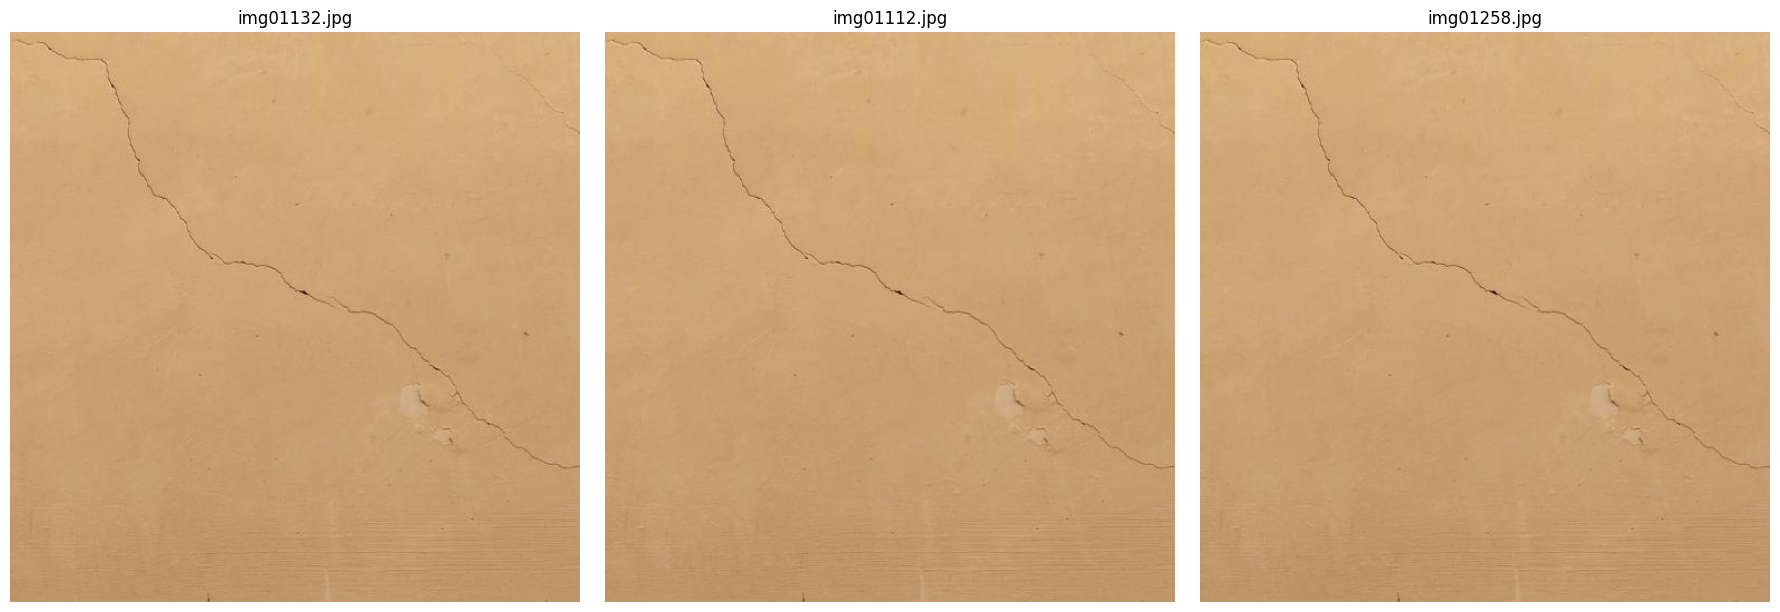

In [40]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(18, 6))

for i, filename in enumerate(problem_files, start=1):

    image_path = OLD_PUBLIC_IMAGES / filename

    img = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(
        1,
        len(problem_files),
        i
    )

    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 39. Visualisation of Conflicting Duplicate Annotations

The class-inconsistent exact-duplicate group is visualised with its individual
YOLO bounding-box annotations.

This enables direct comparison of the competing annotations and supports
manual selection of the most appropriate annotation before duplicate
consolidation.

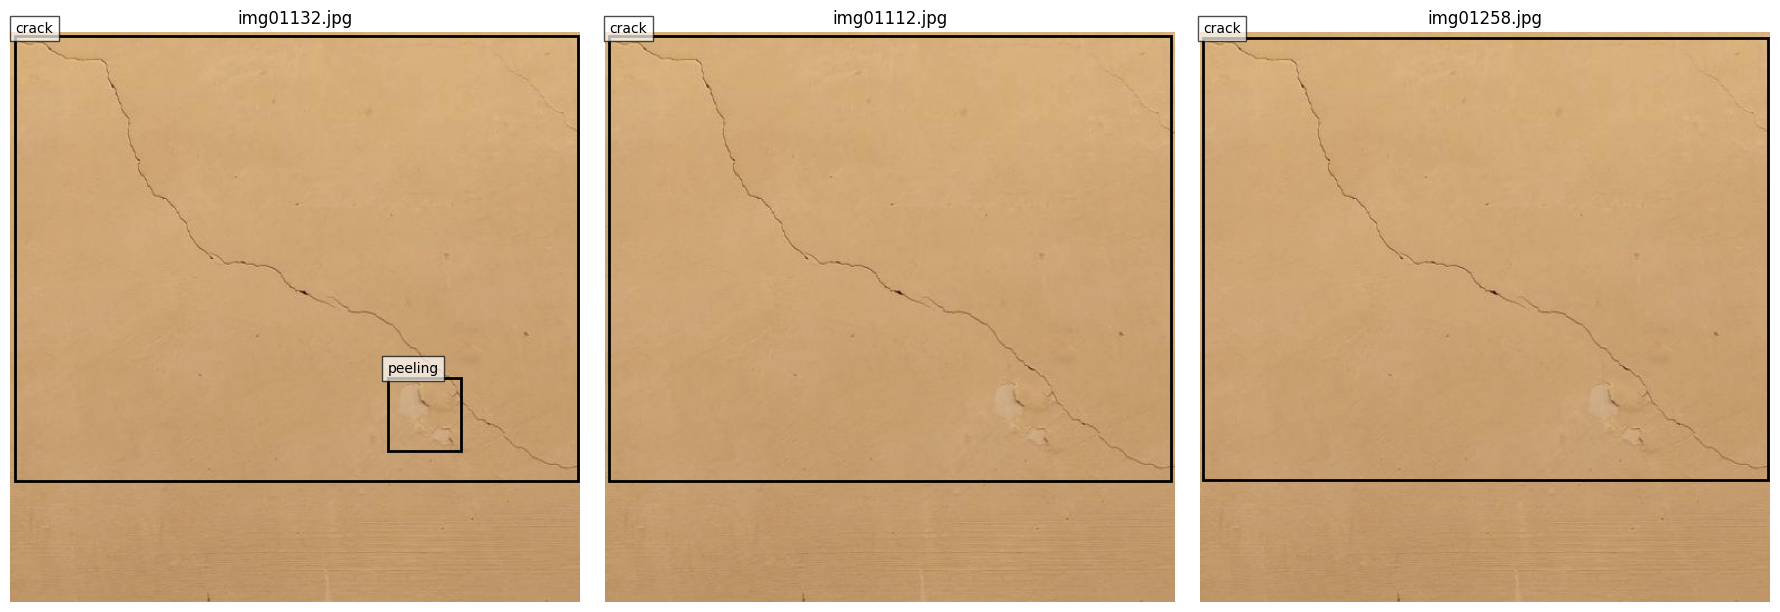

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

problem_files = [
    "img01132.jpg",
    "img01112.jpg",
    "img01258.jpg"
]

plt.figure(figsize=(18, 6))

for plot_idx, filename in enumerate(problem_files, start=1):

    image_path = OLD_PUBLIC_IMAGES / filename
    label_path = OLD_PUBLIC_LABELS / f"{Path(filename).stem}.txt"

    img = Image.open(image_path).convert("RGB")

    width, height = img.size

    ax = plt.subplot(1, 3, plot_idx)

    ax.imshow(img)

    annotations = read_yolo_annotation(label_path)

    for class_id, bbox in annotations:

        x_center, y_center, box_width, box_height = bbox

        # Convert YOLO normalized coordinates to pixels
        x1 = (x_center - box_width / 2) * width
        y1 = (y_center - box_height / 2) * height

        pixel_width = box_width * width
        pixel_height = box_height * height

        rectangle = patches.Rectangle(
            (x1, y1),
            pixel_width,
            pixel_height,
            linewidth=2,
            fill=False
        )

        ax.add_patch(rectangle)

        class_name = CLASS_NAMES.get(
            class_id,
            f"class_{class_id}"
        )

        ax.text(
            x1,
            max(0, y1 - 5),
            class_name,
            fontsize=10,
            bbox=dict(
                facecolor="white",
                alpha=0.7
            )
        )

    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 40. Bounding-Box Variation Within Exact-Duplicate Groups

Bounding-box annotations from identical images are compared quantitatively.

The purpose is to determine whether annotation differences primarily represent
minor coordinate variation or substantial disagreement in defect localisation.

In [42]:
def bbox_iou(box1, box2):
    """
    Calculate IoU between two YOLO-format boxes:
    (x_center, y_center, width, height)
    """

    x1c, y1c, w1, h1 = box1
    x2c, y2c, w2, h2 = box2

    x1_min = x1c - w1 / 2
    y1_min = y1c - h1 / 2
    x1_max = x1c + w1 / 2
    y1_max = y1c + h1 / 2

    x2_min = x2c - w2 / 2
    y2_min = y2c - h2 / 2
    x2_max = x2c + w2 / 2
    y2_max = y2c + h2 / 2

    inter_x1 = max(x1_min, x2_min)
    inter_y1 = max(y1_min, y2_min)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)

    intersection = inter_w * inter_h

    area1 = w1 * h1
    area2 = w2 * h2

    union = area1 + area2 - intersection

    if union == 0:
        return 0

    return intersection / union

## 41. Same-Class Bounding-Box Agreement Analysis

For each exact-duplicate group, bounding boxes belonging to the same defect
class are compared using Intersection over Union (IoU).

High IoU values indicate minor annotation-coordinate variation, whereas low
IoU values indicate substantial localisation disagreement requiring further
quality-control review.

In [43]:
from itertools import combinations

bbox_agreement_records = []

for sha256, group in exact_duplicate_df.groupby("sha256"):

    files = group["filename"].tolist()

    for file1, file2 in combinations(files, 2):

        label1 = OLD_PUBLIC_LABELS / f"{Path(file1).stem}.txt"
        label2 = OLD_PUBLIC_LABELS / f"{Path(file2).stem}.txt"

        ann1 = read_yolo_annotation(label1)
        ann2 = read_yolo_annotation(label2)

        classes1 = set(a[0] for a in ann1)
        classes2 = set(a[0] for a in ann2)

        common_classes = classes1.intersection(classes2)

        for class_id in common_classes:

            boxes1 = [
                bbox for cls, bbox in ann1
                if cls == class_id
            ]

            boxes2 = [
                bbox for cls, bbox in ann2
                if cls == class_id
            ]

            # Calculate best IoU between boxes
            ious = []

            for b1 in boxes1:
                for b2 in boxes2:
                    ious.append(
                        bbox_iou(b1, b2)
                    )

            best_iou = max(ious) if ious else None

            bbox_agreement_records.append({
                "sha256": sha256,
                "file_1": file1,
                "file_2": file2,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "best_bbox_iou": best_iou
            })


bbox_agreement_df = pd.DataFrame(
    bbox_agreement_records
)

display(
    bbox_agreement_df
    .sort_values("best_bbox_iou")
    .head(30)
)

,sha256,file_1,file_2,class_id,class_name,best_bbox_iou
54,a0415ed1eea89263415ba5b2320f9b655b053c0af060b5...,img03010.jpg,img02685.jpg,1,stain,0.764508
55,a0f179ff8ef838721f264db06ca26364a9337511f2e57d...,img02733.jpg,img03109.jpg,1,stain,0.767065
42,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,img01301.jpg,img01206.jpg,2,crack,0.779613
51,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,img01059.jpg,img01206.jpg,2,crack,0.786386
49,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,img01257.jpg,img01206.jpg,2,crack,0.804150
46,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,img01402.jpg,img01206.jpg,2,crack,0.813717
52,8ff93f11f3c6c8a21c97642fd1d1776285a887367c6a3e...,img01053.jpg,img01206.jpg,2,crack,0.820577
0,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...,img01039.jpg,img01073.jpg,2,crack,0.840960
30,77d041a89f9729181422761cecb2301f99e4ef25e1c844...,img00096.jpg,img00133.jpg,0,biological_growth,0.873358
63,b45498bf10958d6b0d4b8aac4d4c25c176f1b5b880da0f...,img00668.jpg,img01291.jpg,2,crack,0.882243


## 42. Bounding-Box Agreement Summary

The distribution of IoU agreement between annotations of identical images is
summarised to quantify annotation variability within the duplicate groups.

In [44]:
print("=" * 70)
print("BOUNDING-BOX AGREEMENT SUMMARY")
print("=" * 70)

print(
    bbox_agreement_df["best_bbox_iou"].describe()
)

print("\nAgreement categories:")

print(
    "IoU >= 0.90 :",
    (
        bbox_agreement_df["best_bbox_iou"] >= 0.90
    ).sum()
)

print(
    "IoU 0.75–0.90:",
    (
        (bbox_agreement_df["best_bbox_iou"] >= 0.75) &
        (bbox_agreement_df["best_bbox_iou"] < 0.90)
    ).sum()
)

print(
    "IoU 0.50–0.75:",
    (
        (bbox_agreement_df["best_bbox_iou"] >= 0.50) &
        (bbox_agreement_df["best_bbox_iou"] < 0.75)
    ).sum()
)

print(
    "IoU < 0.50:",
    (
        bbox_agreement_df["best_bbox_iou"] < 0.50
    ).sum()
)

BOUNDING-BOX AGREEMENT SUMMARY
count    75.000000
mean      0.942166
std       0.057424
min       0.764508
25%       0.937566
50%       0.961528
75%       0.977661
max       0.996056
Name: best_bbox_iou, dtype: float64

Agreement categories:
IoU >= 0.90 : 64
IoU 0.75–0.90: 11
IoU 0.50–0.75: 0
IoU < 0.50: 0


Identify Non-Exact Candidates with pHash Distance 0

In [45]:
phash_zero_df = (
    true_near_duplicates[
        true_near_duplicates["phash_distance"] == 0
    ]
    .copy()
)

print("=" * 70)
print("NON-EXACT pHASH = 0 CANDIDATES")
print("=" * 70)

print(
    "Number of candidate pairs:",
    len(phash_zero_df)
)

display(
    phash_zero_df[
        [
            "dataset_1",
            "filename_1",
            "dataset_2",
            "filename_2",
            "phash_distance"
        ]
    ]
)

NON-EXACT pHASH = 0 CANDIDATES
Number of candidate pairs: 5


,dataset_1,filename_1,dataset_2,filename_2,phash_distance
75,old_public,img01448.jpg,old_public,img01740.jpg,0
114,new_public,din_12.jpg,new_public,din_57.jpg,0
115,new_public,din_12.jpg,new_public,din_97.jpg,0
116,new_public,din_57.jpg,new_public,din_97.jpg,0
126,external_field,IMG_0844.JPG,external_field,IMG_0845.JPG,0


Visualise pHash-Zero Candidate Pairs

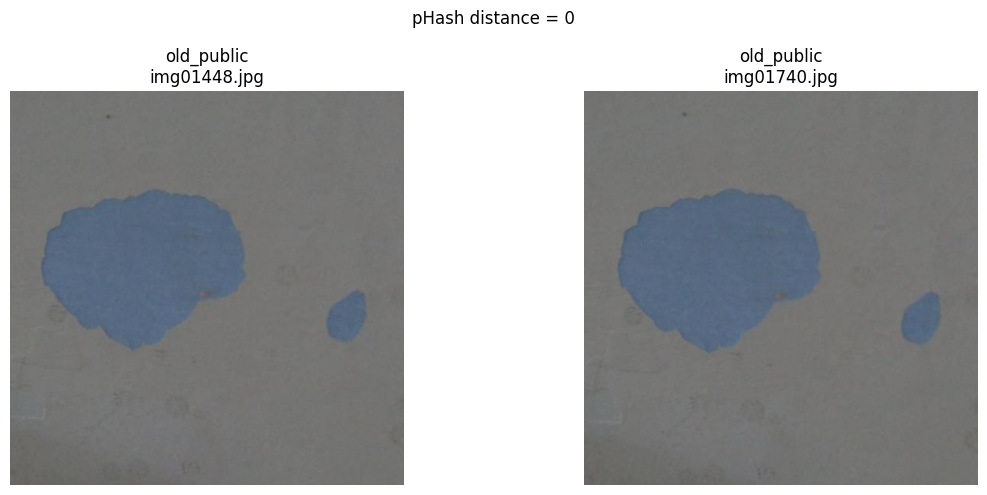

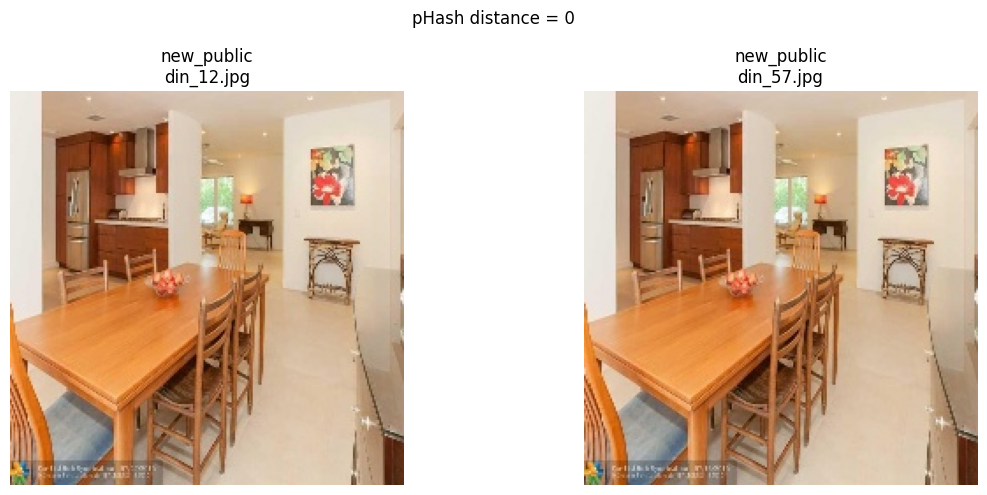

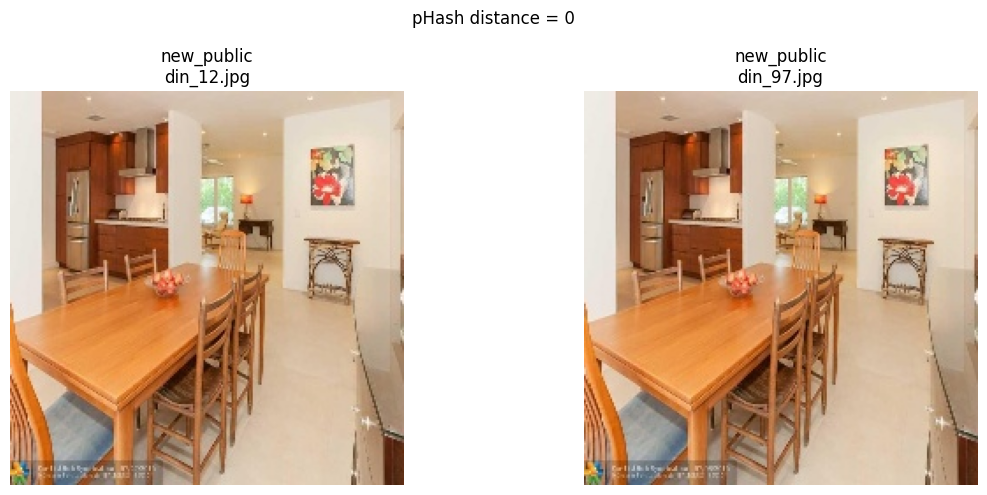

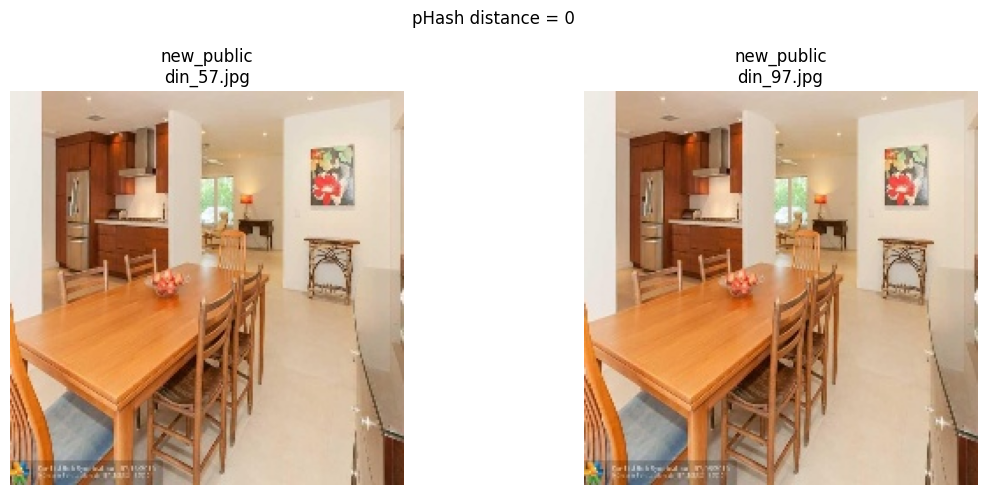

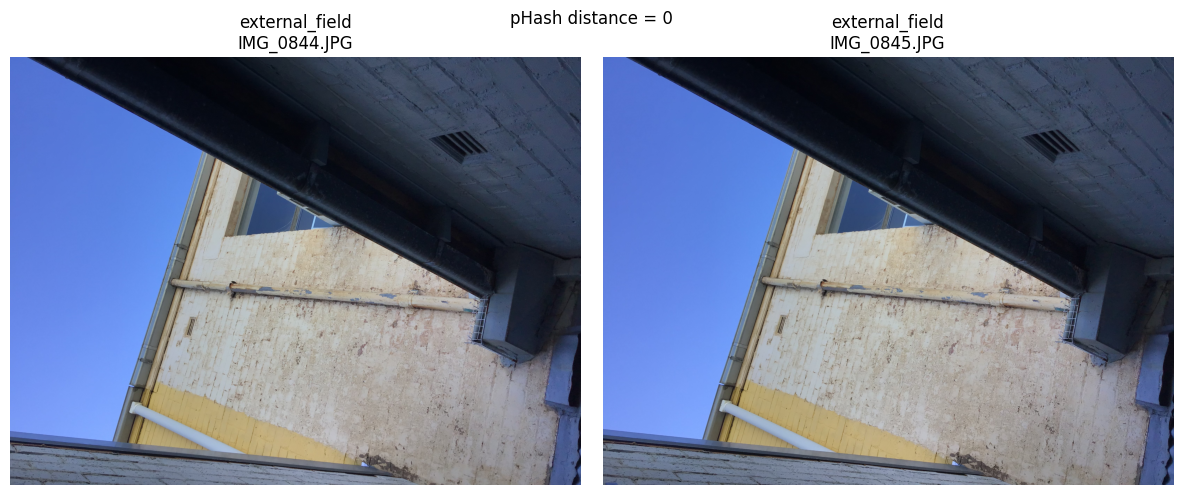

In [46]:
def get_image_path(dataset_name, filename):

    dataset_paths = {
        "old_public": OLD_PUBLIC_IMAGES,
        "new_public": NEW_PUBLIC_IMAGES,
        "external_field": FIELD_IMAGES
    }

    return dataset_paths[dataset_name] / filename


for idx, row in phash_zero_df.iterrows():

    path1 = get_image_path(
        row["dataset_1"],
        row["filename_1"]
    )

    path2 = get_image_path(
        row["dataset_2"],
        row["filename_2"]
    )

    img1 = Image.open(path1).convert("RGB")
    img2 = Image.open(path2).convert("RGB")

    plt.figure(figsize=(12, 5))

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(img1)
    ax1.set_title(
        f'{row["dataset_1"]}\n{row["filename_1"]}'
    )
    ax1.axis("off")

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(img2)
    ax2.set_title(
        f'{row["dataset_2"]}\n{row["filename_2"]}'
    )
    ax2.axis("off")

    plt.suptitle(
        f"pHash distance = {row['phash_distance']}"
    )

    plt.tight_layout()
    plt.show()

## 45. Manual Review Decisions for pHash-Zero Candidates

Perceptually identical candidates were manually reviewed to distinguish true
duplicate photographs from legitimate repeated field observations.

The three `din_*` images represent the same underlying public photograph.
The `img01448` and `img01740` pair also represents the same underlying
photograph. The external-field pair consists of highly similar consecutive
field observations and is retained because the images exhibit slight
viewpoint/framing variation and remain entirely within the independent
external evaluation domain.

In [47]:
manual_near_duplicate_decisions = pd.DataFrame([
    {
        "dataset": "new_public",
        "group": "near_group_001",
        "files": "din_12.jpg | din_57.jpg | din_97.jpg",
        "decision": "same_underlying_image",
        "action": "retain_one"
    },
    {
        "dataset": "old_public",
        "group": "near_group_002",
        "files": "img01448.jpg | img01740.jpg",
        "decision": "same_underlying_image",
        "action": "retain_one"
    },
    {
        "dataset": "external_field",
        "group": "near_group_003",
        "files": "IMG_0844.JPG | IMG_0845.JPG",
        "decision": "similar_but_distinct_field_frames",
        "action": "retain_both"
    }
])

display(manual_near_duplicate_decisions)

,dataset,group,files,decision,action
0,new_public,near_group_001,din_12.jpg | din_57.jpg | din_97.jpg,same_underlying_image,retain_one
1,old_public,near_group_002,img01448.jpg | img01740.jpg,same_underlying_image,retain_one
2,external_field,near_group_003,IMG_0844.JPG | IMG_0845.JPG,similar_but_distinct_field_frames,retain_both


Save Manual Near-Duplicate Review

In [48]:
manual_near_duplicate_decisions.to_csv(
    OUTPUT_DIR / "manual_near_duplicate_review.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR / "manual_near_duplicate_review.csv"
)

Saved: /content/drive/MyDrive/Paper Dataset/Duplicate_Leakage_Check/manual_near_duplicate_review.csv


Create Exact-Duplicate Retention Manifest

In [49]:
exact_manifest_records = []

SPECIAL_KEEP = {
    "img01132.jpg",
    "img01112.jpg",
    "img01258.jpg"
}

for sha256, group in exact_duplicate_df.groupby("sha256"):

    filenames = sorted(
        group["filename"].tolist()
    )

    # Special manually reviewed group
    if "img01132.jpg" in filenames:
        keep_file = "img01132.jpg"
        selection_method = "manual_annotation_review"

    else:
        keep_file = filenames[0]
        selection_method = "systematic_filename_selection"

    for filename in filenames:

        action = (
            "KEEP"
            if filename == keep_file
            else "EXCLUDE_DUPLICATE"
        )

        exact_manifest_records.append({
            "sha256": sha256,
            "filename": filename,
            "group_size": len(filenames),
            "action": action,
            "selection_method": selection_method
        })


exact_cleaning_manifest = pd.DataFrame(
    exact_manifest_records
)

display(exact_cleaning_manifest)

,sha256,filename,group_size,action,selection_method
0,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...,img01039.jpg,2,KEEP,systematic_filename_selection
1,2210a8a8c028c7f63344835e7a39fb40e18917d8f3122b...,img01073.jpg,2,EXCLUDE_DUPLICATE,systematic_filename_selection
2,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,img01042.jpg,5,KEEP,systematic_filename_selection
3,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,img01100.jpg,5,EXCLUDE_DUPLICATE,systematic_filename_selection
4,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,img01231.jpg,5,EXCLUDE_DUPLICATE,systematic_filename_selection
5,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,img01358.jpg,5,EXCLUDE_DUPLICATE,systematic_filename_selection
6,46beed4de497e5f0a94fbf4d00ade6fc96dca237ba89b7...,img01363.jpg,5,EXCLUDE_DUPLICATE,systematic_filename_selection
7,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...,img01227.jpg,5,KEEP,systematic_filename_selection
8,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...,img01261.jpg,5,EXCLUDE_DUPLICATE,systematic_filename_selection
9,4c547e2c014da061d9dd35cda4d3e6a159ca26ddc74dd2...,img01333.jpg,5,EXCLUDE_DUPLICATE,systematic_filename_selection


Summarise Exact-Duplicate Cleaning Manifest

In [50]:
print("=" * 70)
print("EXACT-DUPLICATE CLEANING MANIFEST")
print("=" * 70)

print(
    exact_cleaning_manifest[
        "action"
    ].value_counts()
)

print(
    "\nOriginal exact-duplicate files:",
    len(exact_cleaning_manifest)
)

print(
    "Unique representatives:",
    (
        exact_cleaning_manifest["action"]
        == "KEEP"
    ).sum()
)

print(
    "Redundant exact copies to exclude:",
    (
        exact_cleaning_manifest["action"]
        == "EXCLUDE_DUPLICATE"
    ).sum()
)

EXACT-DUPLICATE CLEANING MANIFEST
action
EXCLUDE_DUPLICATE    38
KEEP                 18
Name: count, dtype: int64

Original exact-duplicate files: 56
Unique representatives: 18
Redundant exact copies to exclude: 38


Add Manually Confirmed Near-Duplicate Exclusions

In [51]:
near_duplicate_exclusions = pd.DataFrame([
    {
        "dataset": "new_public",
        "filename": "din_57.jpg",
        "representative": "din_12.jpg",
        "reason": "confirmed_same_underlying_image"
    },
    {
        "dataset": "new_public",
        "filename": "din_97.jpg",
        "representative": "din_12.jpg",
        "reason": "confirmed_same_underlying_image"
    },
    {
        "dataset": "old_public",
        "filename": "img01740.jpg",
        "representative": "img01448.jpg",
        "reason": "confirmed_same_underlying_image"
    }
])

display(near_duplicate_exclusions)

,dataset,filename,representative,reason
0,new_public,din_57.jpg,din_12.jpg,confirmed_same_underlying_image
1,new_public,din_97.jpg,din_12.jpg,confirmed_same_underlying_image
2,old_public,img01740.jpg,img01448.jpg,confirmed_same_underlying_image


Save Cleaning Manifests

In [52]:
exact_cleaning_manifest.to_csv(
    OUTPUT_DIR / "exact_duplicate_cleaning_manifest.csv",
    index=False
)

near_duplicate_exclusions.to_csv(
    OUTPUT_DIR / "confirmed_near_duplicate_exclusions.csv",
    index=False
)

print("=" * 70)
print("CLEANING MANIFESTS SAVED")
print("=" * 70)

print(
    "Exact duplicate exclusions:",
    (
        exact_cleaning_manifest["action"]
        == "EXCLUDE_DUPLICATE"
    ).sum()
)

print(
    "Confirmed near-duplicate exclusions:",
    len(near_duplicate_exclusions)
)

print(
    "\nTotal proposed public exclusions:",
    (
        exact_cleaning_manifest["action"]
        == "EXCLUDE_DUPLICATE"
    ).sum()
    + len(near_duplicate_exclusions)
)

CLEANING MANIFESTS SAVED
Exact duplicate exclusions: 38
Confirmed near-duplicate exclusions: 3

Total proposed public exclusions: 41


Check Overlap Between Exact and Near-Duplicate Exclusions

In [53]:
exact_excluded_files = set(
    exact_cleaning_manifest.loc[
        exact_cleaning_manifest["action"] == "EXCLUDE_DUPLICATE",
        "filename"
    ]
)

near_excluded_files = set(
    near_duplicate_exclusions["filename"]
)

overlap_files = exact_excluded_files.intersection(
    near_excluded_files
)

print("=" * 70)
print("EXCLUSION OVERLAP CHECK")
print("=" * 70)

print("Exact duplicate exclusions :", len(exact_excluded_files))
print("Near-duplicate exclusions  :", len(near_excluded_files))
print("Overlap between lists      :", len(overlap_files))

if overlap_files:
    print("\nOverlapping files:")
    for filename in sorted(overlap_files):
        print(" -", filename)
else:
    print("\nPASS: No duplicate counting detected.")

EXCLUSION OVERLAP CHECK
Exact duplicate exclusions : 38
Near-duplicate exclusions  : 3
Overlap between lists      : 0

PASS: No duplicate counting detected.


Calculate Final Cleaned Dataset Size

In [54]:
ORIGINAL_OLD_PUBLIC = 3204
ORIGINAL_NEW_PUBLIC = 662
ORIGINAL_FIELD = 562

ORIGINAL_PUBLIC_TOTAL = (
    ORIGINAL_OLD_PUBLIC +
    ORIGINAL_NEW_PUBLIC
)

unique_public_exclusions = (
    exact_excluded_files |
    near_excluded_files
)

TOTAL_PUBLIC_EXCLUSIONS = len(
    unique_public_exclusions
)

CLEAN_PUBLIC_TOTAL = (
    ORIGINAL_PUBLIC_TOTAL -
    TOTAL_PUBLIC_EXCLUSIONS
)

FINAL_TOTAL = (
    CLEAN_PUBLIC_TOTAL +
    ORIGINAL_FIELD
)

print("=" * 70)
print("FINAL CLEANED DATASET SIZE")
print("=" * 70)

print(f"Original old public        : {ORIGINAL_OLD_PUBLIC}")
print(f"Original new public        : {ORIGINAL_NEW_PUBLIC}")
print(f"Original public total      : {ORIGINAL_PUBLIC_TOTAL}")
print()

print(f"Exact duplicate exclusions : {len(exact_excluded_files)}")
print(f"Near-duplicate exclusions  : {len(near_excluded_files)}")
print(f"Unique public exclusions   : {TOTAL_PUBLIC_EXCLUSIONS}")
print()

print(f"Clean public development   : {CLEAN_PUBLIC_TOTAL}")
print(f"External field validation  : {ORIGINAL_FIELD}")
print("-" * 45)
print(f"Final usable image corpus  : {FINAL_TOTAL}")

FINAL CLEANED DATASET SIZE
Original old public        : 3204
Original new public        : 662
Original public total      : 3866

Exact duplicate exclusions : 38
Near-duplicate exclusions  : 3
Unique public exclusions   : 41

Clean public development   : 3825
External field validation  : 562
---------------------------------------------
Final usable image corpus  : 4387


Save Final Duplicate Audit Summary

In [55]:
final_duplicate_summary = pd.DataFrame([
    {
        "metric": "Original total images",
        "value": 4428
    },
    {
        "metric": "Original public development images",
        "value": ORIGINAL_PUBLIC_TOTAL
    },
    {
        "metric": "External field images",
        "value": ORIGINAL_FIELD
    },
    {
        "metric": "Exact duplicate groups",
        "value": 18
    },
    {
        "metric": "Exact duplicate files excluded",
        "value": len(exact_excluded_files)
    },
    {
        "metric": "Confirmed near-duplicate files excluded",
        "value": len(near_excluded_files)
    },
    {
        "metric": "Overlap between exclusion lists",
        "value": len(overlap_files)
    },
    {
        "metric": "Unique public images excluded",
        "value": TOTAL_PUBLIC_EXCLUSIONS
    },
    {
        "metric": "Clean public development images",
        "value": CLEAN_PUBLIC_TOTAL
    },
    {
        "metric": "Retained external field images",
        "value": ORIGINAL_FIELD
    },
    {
        "metric": "Final usable image corpus",
        "value": FINAL_TOTAL
    },
    {
        "metric": "Detected public-field duplicate overlap",
        "value": 0
    }
])

display(final_duplicate_summary)

final_duplicate_summary.to_csv(
    OUTPUT_DIR / "final_duplicate_leakage_summary.csv",
    index=False
)

print(
    "\nSaved:",
    OUTPUT_DIR / "final_duplicate_leakage_summary.csv"
)

,metric,value
0,Original total images,4428
1,Original public development images,3866
2,External field images,562
3,Exact duplicate groups,18
4,Exact duplicate files excluded,38
5,Confirmed near-duplicate files excluded,3
6,Overlap between exclusion lists,0
7,Unique public images excluded,41
8,Clean public development images,3825
9,Retained external field images,562



Saved: /content/drive/MyDrive/Paper Dataset/Duplicate_Leakage_Check/final_duplicate_leakage_summary.csv


## 54. Duplicate and Leakage Audit Conclusion

The duplicate and leakage audit screened all 4,428 images using cryptographic
SHA-256 hashing, perceptual hashing, cross-source comparison, annotation
consistency analysis, and manual verification of high-similarity candidates.

Exact duplicate images were confined to the original public dataset, with no
exact duplication detected across dataset sources. Eighteen exact-duplicate
groups containing 56 images were identified, resulting in 38 redundant copies
being marked for exclusion while retaining one representative from each group.

Perceptual-hash screening identified additional visually similar candidates.
Manual review confirmed three redundant public images for exclusion, while
highly similar but distinct field observations were retained. No duplicate
contamination was identified between the public development corpus and the
independent external field-validation dataset.

All cleaning decisions were recorded through reproducible manifests rather
than modifying the original source datasets. The resulting cleaned public
development corpus will therefore be used for subsequent dataset construction
and frozen train-validation-test partitioning.